In [2]:
import os
import sys

import json
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
if os.path.basename(os.getcwd()) == "notebooks":
    PROJECT_ROOT = os.path.abspath("..")
else:
    PROJECT_ROOT = os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

/home/dantimson/ML_NLP/IAD25-ML-NLP-lab


In [ ]:
from src.preprocess import (
    ID2TAG,
    TAG2ID,
    load_csv,
    build_sentence_examples,
    train_valid_split_balanced,
)

from src.metrics import entity_level_prf1

from src.crf import CRFNER

from src.tf import TransformerNER, TransformerConfig

from src.entity import EntityStore

from src.entity_ingest import ingest_examples, spans_from_iob

from src.visualize import highlight_entities_html, plot_category_wordcloud

In [5]:
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")

In [6]:
TRAIN_CRF = False
TRAIN_TF = False
SHOW_PROGRESS = True

CRF_CHECKPOINT = os.path.join(MODEL_DIR, "crf_ner.joblib")
TF_CHECKPOINT = os.path.join(MODEL_DIR, "distilbert_ner")

In [ ]:
train_df = load_csv(TRAIN_PATH, has_labels=True)
test_df = load_csv(TEST_PATH, has_labels=False)

train_examples = build_sentence_examples(train_df, has_labels=True)
test_examples = build_sentence_examples(test_df, has_labels=False)

print(len(train_df), len(test_df))
print(len(train_examples), len(test_examples))
train_df.head()

839364 209211
38367 9592


,row_id,Sentence_id,Word,POS,Tag,Tag_str
0,0,1,Thousands,NNS,0,O
1,1,1,of,IN,0,O
2,2,1,demonstrators,NNS,0,O
3,3,1,have,VBP,0,O
4,4,1,marched,VBN,0,O


In [8]:
tag_counts = train_df["Tag_str"].value_counts()
tag_counts

Tag_str
O        710524
B-geo     30338
B-tim     16239
B-org     16140
I-per     13903
B-per     13573
I-org     13462
B-gpe     12662
I-geo      5987
I-tim      5152
B-art       321
B-eve       252
I-art       241
I-eve       206
B-nat       164
I-gpe       155
I-nat        45
Name: count, dtype: int64

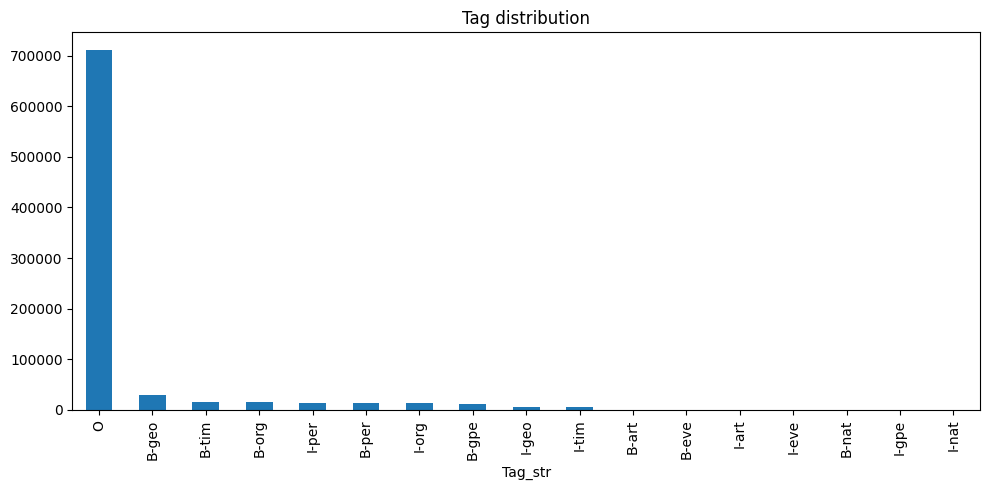

In [9]:
plt.figure(figsize=(10, 5))
tag_counts.plot(kind="bar")
plt.title("Tag distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "tag_distribution.png"))
plt.show()

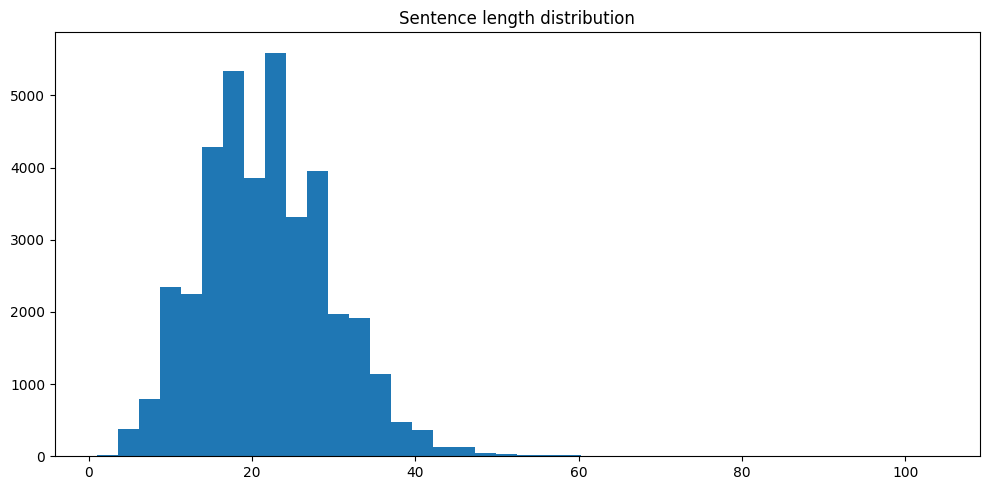

In [10]:
sentence_lengths = [len(ex.tokens) for ex in train_examples]

plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=40)
plt.title("Sentence length distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sentence_length_distribution.png"))
plt.show()

In [11]:
train_split, valid_split = train_valid_split_balanced(
    train_examples,
    valid_size=0.2,
    random_state=42,
)

len(train_split), len(valid_split)

(30692, 7675)

In [12]:
crf_model = CRFNER(show_progress=SHOW_PROGRESS)

if TRAIN_CRF or not os.path.exists(CRF_CHECKPOINT):
    print("Training CRF...")
    crf_model.fit(train_split)
    crf_model.save(CRF_CHECKPOINT)
else:
    print("Loading CRF from checkpoint...")
    crf_model.load(CRF_CHECKPOINT)

crf_pred = crf_model.predict(valid_split)
y_true = [x.ner_tags for x in valid_split]

crf_scores = entity_level_prf1(y_true, crf_pred)
crf_scores

Loading CRF from checkpoint...


CRF predict features: 100%|██████████| 7675/7675 [00:00<00:00, 12055.22it/s]


{'precision': 0.8540929329832173,
 'recall': 0.8399483523269522,
 'f1': 0.8469615918032323,
 'tp': 14962,
 'fp': 2556,
 'fn': 2851}

In [13]:
# tf_config = TransformerConfig(
#     model_name="distilbert-base-cased",
#     max_length=128,
#     output_dir=TF_CHECKPOINT,
#     learning_rate=2e-5,
#     train_batch_size=16,
#     eval_batch_size=16,
#     num_train_epochs=3,
#     show_progress=SHOW_PROGRESS,
# )

tf_config = TransformerConfig(
    model_name="bert-base-cased",
    max_length=128,
    output_dir=TF_CHECKPOINT,
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=16,
    num_train_epochs=4,
    show_progress=SHOW_PROGRESS,
)

tf_model = TransformerNER(tf_config)

checkpoint_exists = os.path.exists(TF_CHECKPOINT) and os.path.exists(os.path.join(TF_CHECKPOINT, "config.json"))

if TRAIN_TF or not checkpoint_exists:
    print("Training transformer...")
    tf_model.fit(train_split, valid_split, do_train=True)
else:
    print("Loading transformer from checkpoint...")
    tf_model.load(TF_CHECKPOINT)

tf_pred = tf_model.predict(valid_split)
tf_scores = entity_level_prf1(y_true, tf_pred)
tf_scores

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1183.14it/s]
BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expec

Loading transformer from checkpoint...


Transformer predict: 100%|██████████| 7675/7675 [02:28<00:00, 51.65it/s] 


{'precision': 0.8410923855609322,
 'recall': 0.8489305563352607,
 'f1': 0.8449932945909701,
 'tp': 15122,
 'fp': 2857,
 'fn': 2691}

In [14]:
store = EntityStore()

best_name = "DistilBERT" if tf_scores["f1"] >= crf_scores["f1"] else "CRF"
best_pred = tf_pred if best_name == "DistilBERT" else crf_pred

ingest_examples(store, valid_split, best_pred, show_progress=SHOW_PROGRESS)

print("Best model:", best_name)
print("Entities:", len(store.entities))
print("Categories:", sorted(store.categories))

Ingest entities: 100%|██████████| 7675/7675 [00:00<00:00, 21699.29it/s]

Best model: CRF
Entities: 5008
Categories: ['art', 'eve', 'geo', 'gpe', 'nat', 'org', 'per', 'tim']


In [15]:
def choose_best_sentence_pred(tf_tags, crf_tags):
    tf_has_entity = any(tag != "O" for tag in tf_tags)
    crf_has_entity = any(tag != "O" for tag in crf_tags)

    if not tf_has_entity and crf_has_entity:
        return crf_tags
    return tf_tags

blended_pred = [
    choose_best_sentence_pred(tf_seq, crf_seq)
    for tf_seq, crf_seq in zip(tf_pred, crf_pred)
]

In [16]:
blended_scores = entity_level_prf1(y_true, blended_pred)
blended_scores

{'precision': 0.8397691966267199,
 'recall': 0.8497164991859878,
 'f1': 0.8447135641934312,
 'tp': 15136,
 'fp': 2888,
 'fn': 2677}

In [17]:
comparison = pd.DataFrame([
    {"model": "CRF", **crf_scores},
    {"model": "DistilBERT", **tf_scores},
    {"model": "blended", **blended_scores},
])
comparison

,model,precision,recall,f1,tp,fp,fn
0,CRF,0.854093,0.839948,0.846962,14962,2556,2851
1,DistilBERT,0.841092,0.848931,0.844993,15122,2857,2691
2,blended,0.839769,0.849716,0.844714,15136,2888,2677


In [ ]:
store.add_entity("ChatGPT", "org", description="An AI assistant system.")
store.get_entity_overview("ChatGPT")

{'canonical_name': 'ChatGPT',
 'category': 'org',
 'description': 'An AI assistant system.',
 'aliases': [],
 'num_mentions': 0,
 'related_texts': []}

In [ ]:
store.reassign_entity("ChatGPT", "art")
store.get_entity_overview("ChatGPT")

{'canonical_name': 'ChatGPT',
 'category': 'art',
 'description': 'An AI assistant system.',
 'aliases': [],
 'num_mentions': 0,
 'related_texts': []}

In [ ]:
store.delete_entity("ChatGPT")
store.get_entity_overview("ChatGPT")

In [ ]:
sample_entity = next(iter(store.entities.keys()))
store.get_entity_overview(sample_entity)

{'canonical_name': 'recent',
 'category': 'tim',
 'description': '',
 'aliases': [],
 'num_mentions': 18,
 'related_texts': ['That tradition has grown in popularity in recent years , driven in part by the 1993 film comedy Groundhog Day .',
  "Zambia 's economy has experienced strong growth in recent years , with real GDP growth in 2005 - 10 about 6 % per year .",
  'Officials said more frequent flooding and accelerating erosion in recent years has routinely damaged houses and boosted waterborne diseases in the population .',
  'Jolo is where the al-Qaida-linked militant group Abu Sayyaf has carried out bombings , kidnappings and killings of foreigners in recent years .',
  'China has been increasing its presence in Africa in recent years , in an effort to secure more markets and materials for its booming economy .',
  'Annual tourist entries have exceeded one-half million in recent years , but financial difficulties in Japan have caused a temporary slowdown .',
  "Rwandan troops have e

In [ ]:
store.get_related_texts(sample_entity)[:3]

['That tradition has grown in popularity in recent years , driven in part by the 1993 film comedy Groundhog Day .',
 "Zambia 's economy has experienced strong growth in recent years , with real GDP growth in 2005 - 10 about 6 % per year .",
 'Officials said more frequent flooding and accelerating erosion in recent years has routinely damaged houses and boosted waterborne diseases in the population .']

In [ ]:
store.explain_word(sample_entity)

"'recent' is known as category 'tim' with 18 stored mention(s)."

In [ ]:
from IPython.display import HTML

idx = 0
HTML(highlight_entities_html(valid_split[idx].tokens, best_pred[idx]))

In [ ]:
# for cat in sorted(store.categories):
#     plot_category_wordcloud(
#         store,
#         cat,
#         save_path=os.path.join(FIG_DIR, f"wordcloud_{cat}.png"),
#     )

In [ ]:
# if best_name == "DistilBERT":
#     test_pred = tf_model.predict(test_examples)
# else:
#     test_pred = crf_model.predict(test_examples)
    
test_pred = tf_model.predict(test_examples)

Transformer predict: 100%|██████████| 9592/9592 [04:33<00:00, 35.08it/s]


In [18]:
def blend_predictions(tf_pred, crf_pred):
    return [
        choose_best_sentence_pred(tf_seq, crf_seq)
        for tf_seq, crf_seq in zip(tf_pred, crf_pred)
    ]

In [19]:
test_pred_tf = tf_model.predict(test_examples)
test_pred_crf = crf_model.predict(test_examples)
test_pred = blend_predictions(test_pred_tf, test_pred_crf)

CRF predict features: 100%|██████████| 9592/9592 [00:00<00:00, 12180.05it/s]


In [20]:
rows = []
for ex, pred_tags in zip(test_examples, test_pred):
    if len(pred_tags) < len(ex.row_ids):
        pred_tags = pred_tags + ["O"] * (len(ex.row_ids) - len(pred_tags))
    elif len(pred_tags) > len(ex.row_ids):
        pred_tags = pred_tags[:len(ex.row_ids)]

    pred_ids = [TAG2ID[tag] for tag in pred_tags]
    for row_id, pred_id in zip(ex.row_ids, pred_ids):
        rows.append({"ID": int(row_id), "TARGET": int(pred_id)})

submission = pd.DataFrame(rows).sort_values("ID").reset_index(drop=True)
submission.head()

,ID,TARGET
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [21]:
bad = []

for i, (ex, pred_tags) in enumerate(zip(test_examples, test_pred)):
    if len(ex.tokens) != len(pred_tags):
        bad.append((i, ex.sentence_id, len(ex.tokens), len(pred_tags)))

len(bad), bad[:10]

(0, [])

In [22]:
len(submission), len(test_df)

(209211, 209211)

In [23]:
submission_path = os.path.join(OUTPUT_DIR, "submission.csv")
submission.to_csv(submission_path, index=False)
submission_path

'/home/dantimson/ML_NLP/IAD25-ML-NLP-lab/outputs/submission.csv'